In [1]:
# load Mouse embryo data

In [2]:
import anndata as ad
import scanpy as sc
import pandas as pd
import numpy as np
import scipy.sparse as sp
import scipy.linalg

import scanpy as sc
from collections import Counter
import matplotlib.pyplot as plt


/mnt/disk1/zhangbiao/miniconda3/envs/env_stasage/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
data_path =  './Data/Zebrafish/'
section_name_list = ['zf12', 'zf18', 'zf24']

section_name = 'zf24' + '_stereoseq.h5ad'

adata = sc.read_h5ad(data_path + section_name)
print(adata)

spatial_x = np.array(adata.obs['spatial_x']) * -1
spatial_y = np.array(adata.obs['spatial_y']) * -1

print(spatial_x.reshape(-1,1).shape)
spatial_array = np.concatenate((spatial_x.reshape(-1,1), spatial_y.reshape(-1,1)), axis=1)
print(spatial_array.shape)


adata.obsm['spatial'] = spatial_array
print(Counter(adata.obs['slice']))
adata = adata[adata.obs['slice'].isin([4])]

AnnData object with n_obs × n_vars = 72175 × 26365
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'seurat_clusters', 'spatial_x', 'spatial_y', 'slice', 'time_point', 'bin_annotation', 'colors', 'layer_annotation', 'layer_colors'
    obsm: 'spatial'
    layers: 'counts'
(72175, 1)
(72175, 2)
Counter({7: 6318, 8: 6115, 10: 5968, 6: 5795, 4: 5271, 2: 4873, 5: 4817, 3: 4770, 9: 4708, 1: 4469, 11: 3329, 17: 3305, 13: 2913, 12: 2828, 16: 2558, 15: 2170, 14: 1968})


['#8BA3C7', '#32692b', '#A67EB7', '#6F94CD', '#FEAF16', ..., '#AA0DFE', '#C075A6', '#938F4C', '#2ED9FF', '#6B798E']
Length: 19
Categories (19, object): ['#2ED9FF', '#5A5156', '#6B798E', '#6F94CD', ..., '#F8A19F', '#F6222E', '#FEAF16', '#FFEE6F']


/mnt/disk1/zhangbiao/miniconda3/envs/env_stasage/lib/python3.8/site-packages/scanpy/plotting/_utils.py:431: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + '_colors'] = colors_list


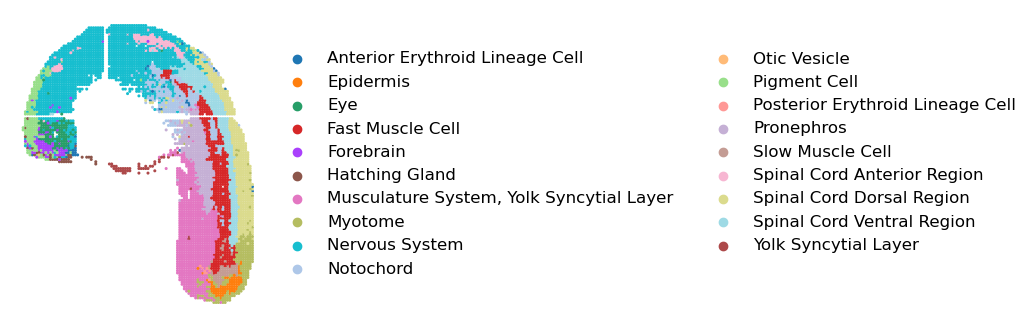

In [4]:
spot_size = 20
title_size = 12
print(adata.obs['colors'].unique())
fig, ax = plt.subplots(1, 1, figsize=(4, 4), gridspec_kw={'wspace': 0.2, 'hspace': 0.1})
sc_obj = sc.pl.spatial(adata, img_key=None, color=['bin_annotation'], title=[''],
                      legend_loc='right margin', legend_fontsize=12, show=True, ax=ax, frameon=False,
                      spot_size=spot_size) #, palette = adata.obs['colors'].unique()

In [5]:
data_path =  './Data/Zebrafish/spatial_sixtime_slice_stereoseq.h5ad'

adata = sc.read_h5ad(data_path)
print(adata)

spatial_x = np.array(adata.obs['spatial_x'])
spatial_y = np.array(adata.obs['spatial_y']) * -1

print(spatial_x.reshape(-1,1).shape)
spatial_array = np.concatenate((spatial_x.reshape(-1,1), spatial_y.reshape(-1,1)), axis=1)
print(spatial_array.shape)


adata.obsm['spatial'] = spatial_array
print(Counter(adata.obs['slice']))
print(Counter(adata.obs['time']))
#adata = adata[adata.obs['slice'].isin([7])]

adata.write_h5ad('./Data/Zebrafish/spatial_sixtime_slice_stereoseq_rotate.h5ad')

AnnData object with n_obs × n_vars = 13166 × 26628
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'seurat_clusters', 'spatial_x', 'spatial_y', 'slice', 'bin_annotation', 'colors', 'layer_annotation', 'layer_colors', 'time'
    layers: 'counts', 'scale.data'
(13166, 1)
(13166, 2)
Counter({4: 5271, 8: 5129, 1: 1167, 11: 1036, 10: 563})
Counter({'24hpf': 5271, '18hpf': 3048, '12hpf': 2081, '3.3hpf': 1167, '10hpf': 1036, '5.25hpf': 563})


['#8BA3C7', '#32692b', '#A67EB7', '#6F94CD', '#FEAF16', ..., '#DA9233', '#f52711', '#BDCDFF', '#A76283', '#E5A84B']
Length: 43
Categories (43, object): ['#1a8a56', '#2C2F3B', '#2ED9FF', '#3B00FB', ..., '#bd0026', '#f1b6da', '#f52711', '#faf72f']


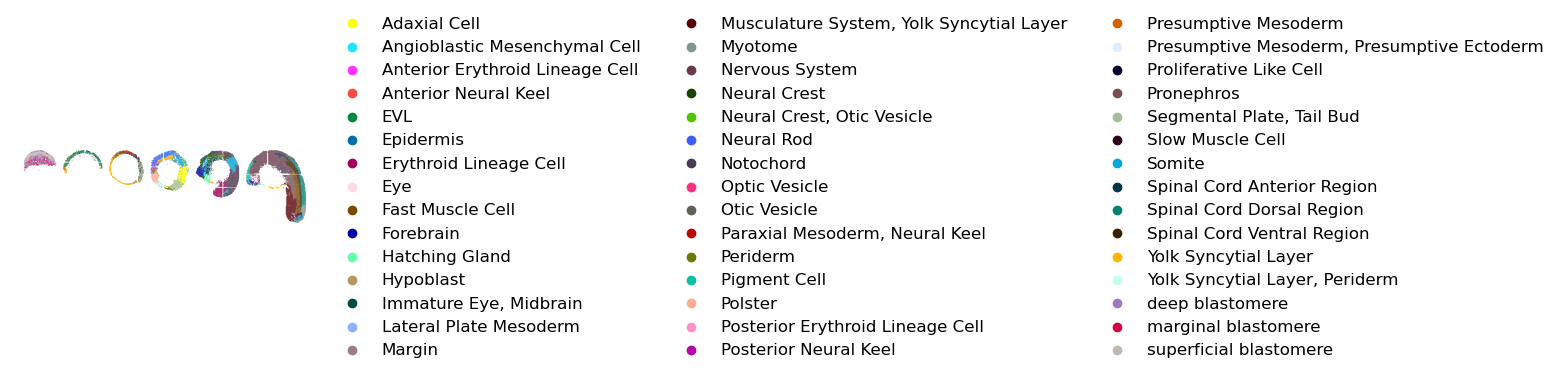

In [6]:
spot_size = 20
title_size = 12
print(adata.obs['colors'].unique())
fig, ax = plt.subplots(1, 1, figsize=(4, 4), gridspec_kw={'wspace': 0.2, 'hspace': 0.1})
sc_obj = sc.pl.spatial(adata, img_key=None, color=['bin_annotation'], title=[''],
                      legend_loc='right margin', legend_fontsize=12, show=True, ax=ax, frameon=False,
                      spot_size=spot_size) #, palette = adata.obs['colors'].unique()


['#8BA3C7', '#32692b', '#A67EB7', '#6F94CD', '#FEAF16', ..., '#DA9233', '#f52711', '#BDCDFF', '#A76283', '#E5A84B']
Length: 43
Categories (43, object): ['#1a8a56', '#2C2F3B', '#2ED9FF', '#3B00FB', ..., '#bd0026', '#f1b6da', '#f52711', '#faf72f']


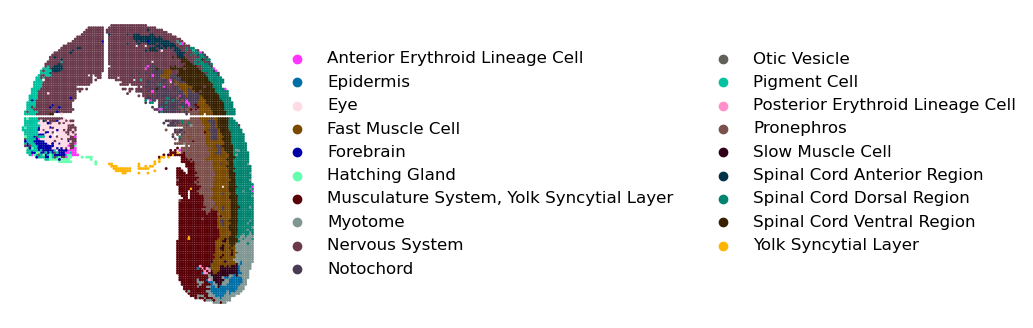

['#8BA3C7', '#32692b', '#A67EB7', '#6F94CD', '#FEAF16', ..., '#DA9233', '#f52711', '#BDCDFF', '#A76283', '#E5A84B']
Length: 43
Categories (43, object): ['#1a8a56', '#2C2F3B', '#2ED9FF', '#3B00FB', ..., '#bd0026', '#f1b6da', '#f52711', '#faf72f']


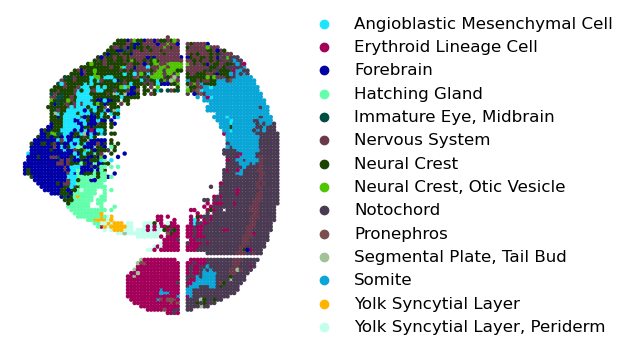

['#8BA3C7', '#32692b', '#A67EB7', '#6F94CD', '#FEAF16', ..., '#DA9233', '#f52711', '#BDCDFF', '#A76283', '#E5A84B']
Length: 43
Categories (43, object): ['#1a8a56', '#2C2F3B', '#2ED9FF', '#3B00FB', ..., '#bd0026', '#f1b6da', '#f52711', '#faf72f']


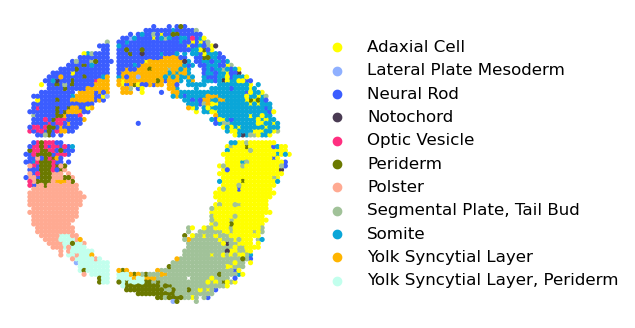

['#8BA3C7', '#32692b', '#A67EB7', '#6F94CD', '#FEAF16', ..., '#DA9233', '#f52711', '#BDCDFF', '#A76283', '#E5A84B']
Length: 43
Categories (43, object): ['#1a8a56', '#2C2F3B', '#2ED9FF', '#3B00FB', ..., '#bd0026', '#f1b6da', '#f52711', '#faf72f']


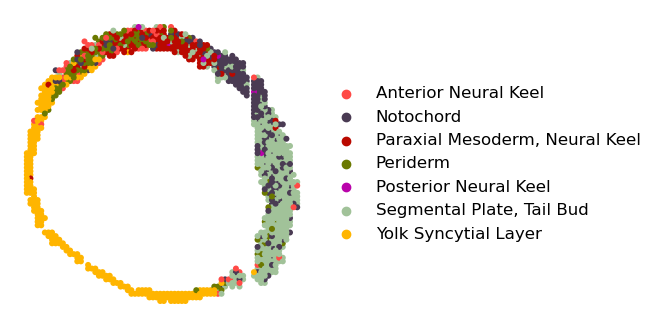

['#8BA3C7', '#32692b', '#A67EB7', '#6F94CD', '#FEAF16', ..., '#DA9233', '#f52711', '#BDCDFF', '#A76283', '#E5A84B']
Length: 43
Categories (43, object): ['#1a8a56', '#2C2F3B', '#2ED9FF', '#3B00FB', ..., '#bd0026', '#f1b6da', '#f52711', '#faf72f']


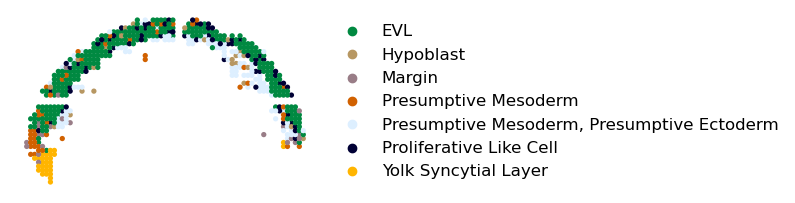

['#8BA3C7', '#32692b', '#A67EB7', '#6F94CD', '#FEAF16', ..., '#DA9233', '#f52711', '#BDCDFF', '#A76283', '#E5A84B']
Length: 43
Categories (43, object): ['#1a8a56', '#2C2F3B', '#2ED9FF', '#3B00FB', ..., '#bd0026', '#f1b6da', '#f52711', '#faf72f']


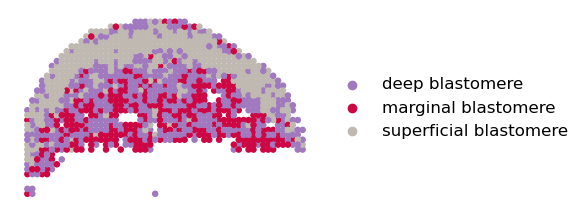

In [7]:
from collections import Counter
for k,v in Counter(adata.obs['time']).items():
    adata_temp = adata[adata.obs['time'].isin([k])]
    adata_temp.write_h5ad(f'../Experiment_embryo_zebrafish_mouse/Data/Zebrafish/Zebrafish_{k}.h5ad')
    spot_size = 20
    title_size = 12
    print(adata.obs['colors'].unique())
    fig, ax = plt.subplots(1, 1, figsize=(4, 4), gridspec_kw={'wspace': 0.2, 'hspace': 0.1})
    sc_obj = sc.pl.spatial(adata_temp, img_key=None, color=['bin_annotation'], title=[''],
                          legend_loc='right margin', legend_fontsize=12, show=True, ax=ax, frameon=False,
                          spot_size=spot_size) #, palette = adata.obs['colors'].unique()

['#8BA3C7', '#32692b', '#A67EB7', '#6F94CD', '#FEAF16', ..., '#BBA1CB', '#FFF799', '#2C2F3B', '#7f3b08', '#313695']
Length: 31
Categories (31, object): ['#1a8a56', '#2C2F3B', '#2ED9FF', '#5A5156', ..., '#FFEE6F', '#FFF799', '#bd0026', '#f1b6da']


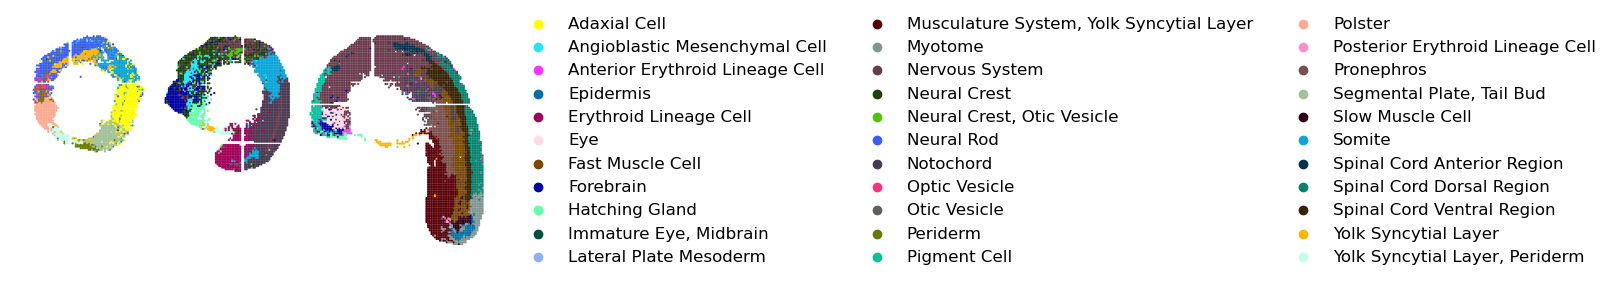

In [13]:
spot_size = 20
title_size = 12
adata = adata[adata.obs['time'].isin(['24hpf', '18hpf', '12hpf'])]
print(adata.obs['colors'].unique())
fig, ax = plt.subplots(1, 1, figsize=(35, 3), gridspec_kw={'wspace': 0.2, 'hspace': 0.1})
sc_obj = sc.pl.spatial(adata, img_key=None, color=['bin_annotation'], title=[''],
                      legend_loc='right margin', legend_fontsize=12, show=True, ax=ax, frameon=False,
                      spot_size=spot_size) #, palette = adata.obs['colors'].unique()
fig.savefig('./figures/zebrafish_annotation.jpg', dpi=500)